# Trabajo Práctico Final: Introducción al Análisis de Datos

**Estudiante:** Fabricio Gastón Alvarez  

**Carrera:** Tecnicatura Universitaria en Programación

**Institución:** Universidad Tecnológica Nacional - Facultad Regional Concepción del Uruguay

**Materia:** Introducción al Análisis de Datos

**Docente:** Joaquín Salazar

**Dataset Seleccionado:** Opción B - Dataset de Spotify

## 1. Exploración inicial del dataset

En este notebook voy a ir desarrollando paso a paso mi trabajo final. Lo primero que tengo que hacer es entender con qué tipo de datos estoy lidiando.

Para arrancar, voy a importar las librerías básicas que aprendimos a usar a lo largo de la materia (`pandas`, `numpy`, `matplotlib` y `seaborn`). Después, voy a cargar el archivo CSV de Spotify para revisar su tamaño, ver qué columnas tiene y mirar las primeras filas para darme una idea general.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuro el estilo de los gráficos para que se vean prolijos
plt.style.use('ggplot')

# Cargo el dataset que subí a mi entorno de trabajo
df = pd.read_csv('Dataset_Spotify - Dataset_Spotify.csv')

# Miro las dimensiones del dataset (filas, columnas)
print(f"El dataset tiene originalmente {df.shape[0]} filas y {df.shape[1]} columnas.\n")

# Reviso los nombres de las columnas y qué tipo de datos guardan
df.info()

El dataset tiene originalmente 114000 filas y 22 columnas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  object 
 3   artists           113999 non-null  object 
 4   album_name        113999 non-null  object 
 5   track_name        113999 non-null  object 
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acoustic

In [3]:
# Le doy un vistazo a las primeras 3 filas para ver la estructura real de los registros
df.head(3)

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


### Mi diagnóstico de la exploración:
Al mirar los resultados, noté que tenemos 114.000 filas. Es un montón de información. Vi que hay variables de todo tipo: de texto (como `artists` o `track_name`), números enteros (`popularity`), números con coma (`danceability`, `energy`) y booleanos (`explicit`).

También me di cuenta de un detalle: las primeras dos columnas (`Unnamed: 0.1` y `Unnamed: 0`) parecen ser índices viejos que quedaron colgados del archivo original y no me sirven para analizar nada. Además, intuyo que debe haber algunos datos repetidos o nulos que voy a tener que corregir en el siguiente paso.

## 2. Limpieza del dataset

Ahora que conozco la estructura, voy a limpiar los datos para que mis análisis sean confiables. Si no limpio el dataset, corro el riesgo de sacar conclusiones falsas.

Voy a tomar las siguientes decisiones de diseño:
1. **Eliminar columnas innecesarias:** Voy a sacar esas columnas `Unnamed` que vi recién.
2. **Tratamiento de nulos:** Voy a revisar si hay celdas vacías en las columnas clave y, si son poquitas, las voy a borrar.
3. **Eliminar duplicados:** En Spotify es común que una canción aparezca repetida si está en varios álbumes o recopilatorios. Voy a usar el `track_id` (que es único) para dejar solo una fila por canción.
4. **Controlar valores atípicos (outliers):** Al revisar la duración en milisegundos (`duration_ms`), noté que hay audios de pocos segundos (errores) y otros larguísimos de más de una hora (como podcasts). Como yo quiero analizar música, decidí quedarme solo con pistas que duren entre 30 segundos y 10 minutos.

In [4]:
# 1. Saco las columnas que no aportan valor
df_limpio = df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'], errors='ignore')

# 2. Busco nulos. Si los hay, los elimino del dataset
print("Cantidad de valores nulos por columna antes de limpiar:")
print(df_limpio.isnull().sum())
df_limpio = df_limpio.dropna(subset=['artists', 'album_name', 'track_name'])

# 3. Elimino los registros duplicados usando el ID de la canción
df_limpio = df_limpio.drop_duplicates(subset=['track_id'])

# 4. Filtro los outliers de tiempo (30 seg = 30.000 ms; 10 min = 600.000 ms)
df_limpio = df_limpio[(df_limpio['duration_ms'] >= 30000) & (df_limpio['duration_ms'] <= 600000)]

print(f"\nLuego de aplicar los filtros de limpieza, nos quedaron {df_limpio.shape[0]} filas listas para usar.")

Cantidad de valores nulos por columna antes de limpiar:
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Luego de aplicar los filtros de limpieza, nos quedaron 89176 filas listas para usar.


## 3. Transformación de datos

Para que trabajar con el dataset sea más cómodo y pueda extraer mejores respuestas, voy a crear 2 columnas nuevas:

- **`duration_min`**: Manejar el tiempo en milisegundos es engorroso. Voy a dividir `duration_ms` por 60.000 para pasar la duración de cada canción a minutos enteros y decimales legibles.
- **`popularidad_categoria`**: La popularidad original va del 0 al 100. Para poder agrupar mejor los datos, voy a crear una función que clasifique este puntaje en tres categorías fijas: si tiene de 0 a 33 puntos será 'Baja', de 34 a 66 será 'Media', y si supera los 66 puntos será 'Alta'.

In [5]:
# Creo la primera columna: duración en minutos
df_limpio['duration_min'] = df_limpio['duration_ms'] / 60000

# Defino la lógica para categorizar la popularidad
def definir_rango_popularidad(valor):
    if valor <= 33:
        return 'Baja'
    elif valor <= 66:
        return 'Media'
    else:
        return 'Alta'

# Aplico la función usando .apply() para armar mi segunda columna nueva
df_limpio['popularidad_categoria'] = df_limpio['popularity'].apply(definir_rango_popularidad)

# Compruebo visualmente cómo quedaron estas nuevas columnas
df_limpio[['track_name', 'duration_min', 'popularity', 'popularidad_categoria']].head()

,track_name,duration_min,popularity,popularidad_categoria
0,Comedy,3.844433,73,Alta
1,Ghost - Acoustic,2.493500,55,Media
2,To Begin Again,3.513767,57,Media
3,Can't Help Falling In Love,3.365550,71,Alta
4,Hold On,3.314217,82,Alta


## 4. Análisis y Visualización

Llegó el momento de plantear preguntas concretas y responderlas apoyándome en herramientas visuales. Como este es un trabajo individual, voy a plantear y responder 2 preguntas clave.

### Pregunta 1: ¿Cuánto influye el género musical en la popularidad de una canción?

Quiero saber si el estilo de música define qué tan popular es un tema en promedio dentro de la plataforma. Para resolver esto, voy a agrupar los datos según la columna `track_genre`, calcular la media de su popularidad, ordenar los resultados de mayor a menor y quedarme con los 10 géneros más populares para hacer un gráfico de barras horizontales.

/tmp/ipykernel_12101/3729926478.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ranking_generos.values, y=ranking_generos.index, palette='coolwarm')


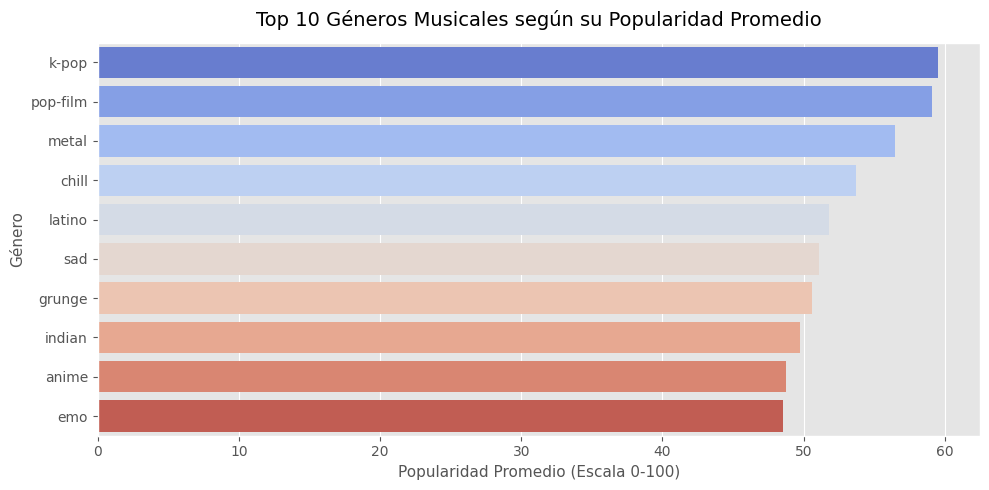

In [6]:
# Agrupo por género y calculo el promedio de popularidad
ranking_generos = df_limpio.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)

# Genero el gráfico de barras horizontales
plt.figure(figsize=(10, 5))
sns.barplot(x=ranking_generos.values, y=ranking_generos.index, palette='coolwarm')

plt.title('Top 10 Géneros Musicales según su Popularidad Promedio', fontsize=14, pad=12)
plt.xlabel('Popularidad Promedio (Escala 0-100)', fontsize=11)
plt.ylabel('Género', fontsize=11)
plt.tight_layout()
plt.show()

**Mi interpretación:** Al mirar el gráfico, queda clarísimo que el género influye de forma directa. El *K-pop* se lleva el primer puesto con un promedio que ronda los 60 puntos, seguido muy de cerca por géneros vinculados a bandas sonoras de películas (*pop-film*) y el *metal*. Esto me dice que los géneros que mueven comunidades de fanáticos muy fieles o de nicho logran traccionar niveles de popularidad base estables mucho más altos que otros estilos comerciales que tal vez están más dispersos en la plataforma.

### Pregunta 2: ¿Existe una relación directa entre la energía de una pista y su capacidad para ser bailable?

Popularmente uno piensa que cuanto más enérgica y rápida es una canción, más invita a bailar. Para comprobar si esto es estadísticamente real, voy a graficar la relación entre las variables `energy` (eje X) y `danceability` (eje Y). Como graficar casi 90.000 puntos haría que el gráfico se empañe por completo, decidí extraer una muestra aleatoria de 5.000 canciones usando un valor de semilla fija (`random_state`) para asegurar la reproducibilidad.

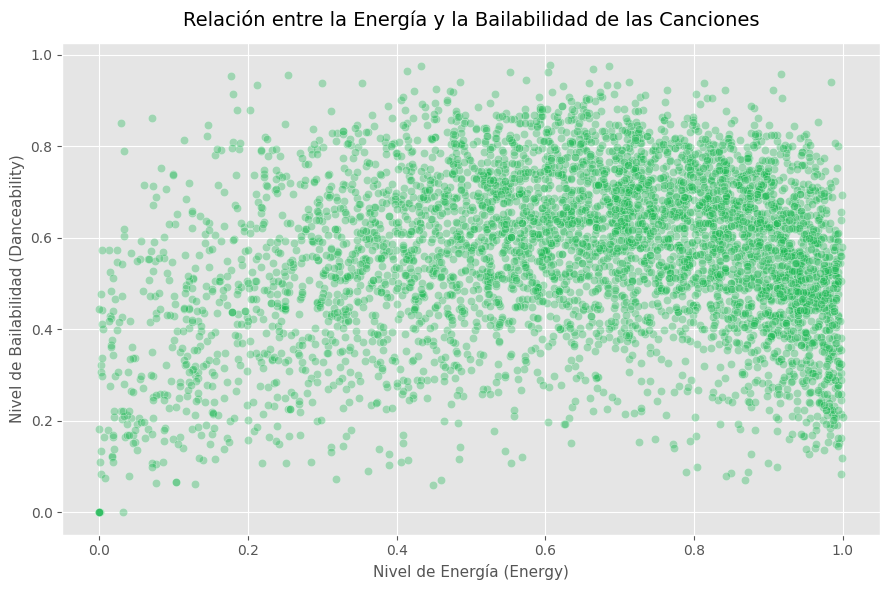

In [7]:
# Extraigo una muestra de 5000 registros para evitar la superposición extrema de puntos
df_muestra = df_limpio.sample(n=5000, random_state=42)

# Dibujo el gráfico de dispersión
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_muestra, x='energy', y='danceability', alpha=0.35, color='#1DB954')

plt.title('Relación entre la Energía y la Bailabilidad de las Canciones', fontsize=14, pad=12)
plt.xlabel('Nivel de Energía (Energy)', fontsize=11)
plt.ylabel('Nivel de Bailabilidad (Danceability)', fontsize=11)
plt.tight_layout()
plt.show()

**Mi interpretación:** El gráfico de dispersión me mostró una sorpresa interesante. Aunque al principio se nota que un nivel moderado de energía ayuda a que la canción sea más bailable, cuando la energía se vuelve extrema (puntos pegados al 1.0 en el eje X), la bailabilidad se viene abajo estrepitosamente. Pensando en términos musicales, esto tiene mucho sentido: canciones con máxima energía acústica corresponden típicamente a géneros veloces y ruidosos como el *grindcore*, el *punk* o el *heavy metal intensivo*. Tienen una fuerza sonora tremenda, pero carecen de los patrones rítmicos estructurados u ordenados que hacen que un tema se pueda bailar en una pista.

## 5. Conclusión General

Para cerrar el trabajo, quiero resumir las lecciones principales que me dejó este análisis. Arrancamos con un volumen gigante de 114.000 registros donde reinaba el ruido (columnas vacías, datos duplicados por cruces de álbumes y audios que eran podcasts de larga duración).

Haber hecho la limpieza adecuada fue el paso del flujo que más impactó en los resultados. Si no hubiese filtrado los duplicados por `track_id` o dejado afuera esas pistas que duraban menos de 30 segundos, los promedios globales de popularidad habrían estado sesgados por canciones repetidas o pistas de ruido blanco.

Gracias a las transformaciones, pudimos mirar la duración en minutos de manera lógica y segmentar los datos en grupos manejables. Al final, las herramientas visuales sirvieron para romper mitos iniciales: descubrí que un exceso de energía destruye la métrica bailable y que la popularidad está fuertemente guiada por los nichos culturales de cada género, teniendo al K-pop a la cabeza. Esta experiencia me demuestra el valor del analista de datos: nuestra tarea no es tirar líneas de código de forma automática, sino tomar decisiones de limpieza y formular preguntas inteligentes para transformar datos crudos en conocimiento útil.